**This code installs the missing software tools needed to read Excel files (openpyxl) and build graphics (seaborn). It then imports Python libraries for database management (sqlite3), data manipulation (pandas), and chart generation (matplotlib & seaborn).**

In [2]:
%pip install seaborn openpyxl

import sqlite3
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

**Set visual style**

In [3]:
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

## 1. LOAD DATA & INITIALIZE SQLITE DATABASE

In [4]:
excel_file = "DataSet.xlsx"

**Read sheets into DataFrames**

In [5]:
sales_df = pd.read_excel(excel_file, sheet_name="SalesItems")
product_df = pd.read_excel(excel_file, sheet_name="ProductItems")

**Create SQLite Database in memory**

In [6]:
conn = sqlite3.connect(":memory:")

**Write DataFrames to SQL tables**

In [7]:
sales_df.to_sql("SalesItems", conn, if_exists="replace", index=False)
product_df.to_sql("ProductItems", conn, if_exists="replace", index=False)

500

**Helper function to run SQL queries and print formatted results**

In [8]:
def run_query(title, query):
  print("=" * 60)
  print(f"  {title}")
  print("=" * 60)
  df_result = pd.read_sql_query(query, conn)
  display(df_result)
  print("\n")
  return df_result

## 2. RUN SQL QUERIES

**Query 1: Overall KPIs**

In [9]:
q1_kpi = """
SELECT 
    COUNT(*) AS total_transactions,
    SUM(quantity) AS total_units_sold,
    ROUND(SUM(item_total), 2) AS total_revenue,
    ROUND(AVG(item_total), 2) AS avg_transaction_value
FROM SalesItems;
"""
df_kpi = run_query("1. Overall Business KPIs", q1_kpi)

  1. Overall Business KPIs


,total_transactions,total_units_sold,total_revenue,avg_transaction_value
0,2253,6715,324236.66,143.91


**Query 2: Performance by Channel & Campaign**

In [10]:
q2_channel = """
SELECT 
    channel,
    channel_campaigns,
    COUNT(*) AS transaction_count,
    SUM(quantity) AS units_sold,
    ROUND(SUM(item_total), 2) AS total_revenue
FROM SalesItems
GROUP BY channel, channel_campaigns
ORDER BY total_revenue DESC;
"""
df_channel = run_query("2. Sales Performance by Channel & Campaign", q2_channel)

  2. Sales Performance by Channel & Campaign


,channel,channel_campaigns,transaction_count,units_sold,total_revenue
0,E-commerce,Website Banner,1151,3480,170513.31
1,App Mobile,App Mobile,963,2940,142892.00
2,App Mobile,Social Media,120,268,9668.94
3,E-commerce,Email,19,27,1162.41


**Query 3: Product Catalog Overview**

In [11]:
q3_products = """
SELECT 
    category,
    gender,
    COUNT(product_id) AS total_products,
    ROUND(AVG(catalog_price), 2) AS avg_catalog_price,
    ROUND(AVG(cost_price), 2) AS avg_cost_price
FROM ProductItems
GROUP BY category, gender
ORDER BY total_products DESC;
"""
df_products = run_query(
    "3. Product Catalog Breakdown by Category & Gender", q3_products
)

  3. Product Catalog Breakdown by Category & Gender


,category,gender,total_products,avg_catalog_price,avg_cost_price
0,Dresses,Female,109,48.61,26.77
1,T-Shirts,Female,108,51.04,27.43
2,Sleepwear,Female,104,47.43,26.79
3,Shoes,Female,100,52.36,29.08
4,Pants,Female,79,50.12,27.21


**Query 4: Transaction Summary by Quantity Sold**

In [12]:
q4_volume = """
SELECT 
    quantity,
    COUNT(*) AS transaction_count,
    ROUND(SUM(item_total), 2) AS total_revenue
FROM SalesItems
GROUP BY quantity
ORDER BY quantity ASC;
"""
df_volume = run_query("4. Transaction Breakdown by Quantity", q4_volume)

  4. Transaction Breakdown by Quantity


,quantity,transaction_count,total_revenue
0,1,455,21596.53
1,2,485,46314.13
2,3,407,59635.06
3,4,461,89833.03
4,5,445,106857.91


## 3. VISUALIZATIONS (CLEAN SYNTAX)

**Chart 1: Revenue by Channel**

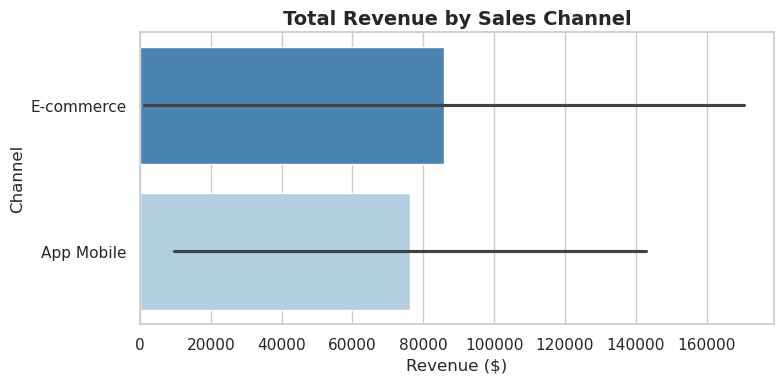

In [13]:
plt.figure(figsize=(8, 4))
sns.barplot(
    data=df_channel,
    x="total_revenue",
    y="channel",
    hue="channel",
    palette="Blues_r",
    legend=False,
)
plt.title("Total Revenue by Sales Channel", fontsize=14, fontweight="bold")
plt.xlabel("Revenue ($)")
plt.ylabel("Channel")
plt.tight_layout()
plt.show()

**Chart 2: Product Count by Category**

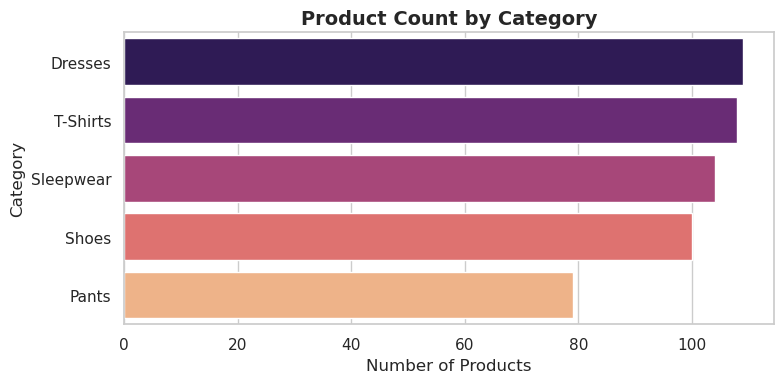

In [14]:
plt.figure(figsize=(8, 4))
sns.barplot(
    data=df_products,
    x="total_products",
    y="category",
    hue="category",
    palette="magma",
    legend=False,
)
plt.title("Product Count by Category", fontsize=14, fontweight="bold")
plt.xlabel("Number of Products")
plt.ylabel("Category")
plt.tight_layout()
plt.show()